## MetroPT-3 Dataset - Qucik analisys

In [16]:
# ── Librerie standard ──────────────────────────────────────────────────────
import time
import os
import warnings
warnings.filterwarnings("ignore") # sopprime i messaggi di deprecazione di Spark

# ── Manipolazione dati ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualizzazione ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Machine Learning (Spark) ───────────────────────────────────────────────
from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import (
    StringIndexer, VectorAssembler,
    ChiSqSelector, UnivariateFeatureSelector,
    VarianceThresholdSelector, StandardScaler
)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# ── Stile globale dei grafici ──────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.family": "DejaVu Sans"})

OUTPUT_DIR = "images/Results/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Analisi

#### Step 2
**Perché usiamo Spark?**

Il dataset MetroPT-3 contiene ~15 milioni di righe raccolte a 1Hz per 6 mesi.
Elaborarlo in locale con Pandas rischierebbe crash o tempi molto lunghi.
Spark distribuisce il lavoro sui **4 worker del cluster**, ognuno con 4 core e 16 GB di RAM.

**Configurazione cluster**

| Parametro | Valore | Motivazione |
|---|---|---|
| `num_executors` | 4 | Un executor per worker |
| `executor_cores` | 4 | Tutti i core disponibili per worker |
| `executor_memory` | 13g | Lasciamo ~3g al SO per evitare OOM |
| `driver_memory` | 8g | Il driver raccoglie i risultati (feature importance, plot) |
| `shuffle.partitions` | 32 | 2 × core totali (16). Il default 200 è pensato per cluster molto più grandi |

**Costruzione del target**
Il dataset è **unlabeled by design**: non esiste una colonna target pronta.
Costruiamo la variabile `target` confrontando il timestamp di ogni riga con le
**4 finestre di guasto** fornite dall'azienda nel report tecnico:

| # | Inizio | Fine | Tipo |
|---|---|---|---|
| 1 | 18/04/2020 00:00 | 18/04/2020 23:59 | Air Leak |
| 2 | 29/05/2020 23:30 | 30/05/2020 06:00 | Air Leak |
| 3 | 05/06/2020 10:00 | 07/06/2020 14:30 | Air Leak |
| 4 | 15/07/2020 14:30 | 15/07/2020 19:00 | Air Leak |

- `target = 1` → guasto in corso
- `target = 0` → funzionamento normale

Il dataset risultante sarà **fortemente sbilanciato**: i guasti coprono poche ore
su 6 mesi di dati. Per questo motivo useremo **F1-score** come metrica principale
invece della semplice accuracy, che sarebbe fuorviante.

**Perché `.cache()`?**
Senza cache, ogni operazione sul DataFrame rileggerebbe il CSV da disco.
Con `.cache()` Spark mantiene il dataset in memoria dopo il primo accesso,
rendendo tutte le operazioni successive molto più veloci.

In [ ]:
# ── Configurazione cluster ─────────────────────────────────────────────────
MASTER_URL   = "spark://10.0.1.8:7077"
DRIVER_HOST  = "10.0.1.8"

spark = SparkSession.builder \
    .appName("MetroPT_Analysis") \
    .master(MASTER_URL) \
    .config("spark.submit.deployMode",      "client") \
    .config("spark.executor.instances",     "4") \
    .config("spark.executor.cores",         "4") \
    .config("spark.executor.memory",        "13g") \
    .config("spark.driver.memory",          "8g") \
    .config("spark.driver.host",            DRIVER_HOST) \
    .config("spark.driver.bindAddress",     DRIVER_HOST) \
    .config("spark.sql.shuffle.partitions", "32") \
    .getOrCreate()
# spark = SparkSession.builder \
#     .appName("MetroPT-EDA") \
#     .master("local[*]") \
#     .config("spark.driver.memory", "8g") \
#     .config("spark.driver.extraJavaOptions", 
#             "--add-opens=java.base/sun.security.action=ALL-UNNAMED "
#             "--add-opens=java.base/java.lang=ALL-UNNAMED") \
#     .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("SparkSession creata — versione:", spark.version)

# ── Caricamento dataset ────────────────────────────────────────────────────
TRAIN_PATH = "file:///home/PuckTrickadmin/DATASETS/MetroDT.csv"
# TRAIN_PATH = "D:\\Users\\satri\\Downloads\\metropt+3+dataset\\MetroPT3(AirCompressor).csv"
t0 = time.time()
df_raw = spark.read.csv(TRAIN_PATH, header=True, inferSchema=True)

# ── Costruzione target dalle finestre di guasto ────────────────────────────
# Il dataset è unlabeled: costruiamo noi la colonna target confrontando
# il timestamp di ogni riga con gli intervalli di guasto noti dal report aziendale.
# 1 = guasto in corso, 0 = normale

failure_windows = [
    ("2020-04-18 00:00:00", "2020-04-18 23:59:00"),
    ("2020-05-29 23:30:00", "2020-05-30 06:00:00"),
    ("2020-06-05 10:00:00", "2020-06-07 14:30:00"),
    ("2020-07-15 14:30:00", "2020-07-15 19:00:00"),
]

# Costruiamo la condizione come OR di tutti gli intervalli
failure_condition = None
for start, end in failure_windows:
    window_cond = (F.col("timestamp") >= start) & (F.col("timestamp") <= end)
    failure_condition = window_cond if failure_condition is None else (failure_condition | window_cond)

if failure_condition is not None:
    df_raw = df_raw.withColumn("target", F.when(failure_condition, 1).otherwise(0))
    df_raw.cache()

    n_rows = df_raw.count()
    n_cols = len(df_raw.columns)
    n_failures = df_raw.filter(F.col("target") == 1).count()

    print(f"Righe      : {n_rows:,}")
    print(f"Colonne    : {n_cols}")
    print(f"Guasti (1) : {n_failures:,} ({n_failures/n_rows*100:.2f}%)")
    print(f"Normali (0): {n_rows - n_failures:,} ({(n_rows-n_failures)/n_rows*100:.2f}%)")
    print(f"Tempo caricamento: {time.time() - t0:.1f}s")

SparkSession creata — versione: 4.1.1
Righe      : 1,516,948
Colonne    : 18
Guasti (1) : 29,954 (1.97%)
Normali (0): 1,486,994 (98.03%)
Tempo caricamento: 5.1s


**Output**
| Metrica | Valore |
|---|---|
| Righe totali | 1,516,948 |
| Colonne | 18 (15 feature + index + timestamp + target) |
| Guasti (target=1) | 29,954 (1.97%) |
| Normali (target=0) | 1,486,994 (98.03%) |
| Tempo caricamento | 8.7s |

**Osservazioni**
Il dataset risulta **fortemente sbilanciato**: i guasti rappresentano meno del 2%
delle osservazioni, il che riflette fedelmente la realtà operativa — i guasti
sono eventi rari rispetto al normale funzionamento del compressore.

Questo sbilanciamento ha due implicazioni dirette per la nostra analisi:
- **Metrica**: useremo **F1-score** invece della accuracy. Con il 98% di normali,
  un modello che predice sempre 0 avrebbe accuracy del 98% pur essendo inutile.
- **Iniezione del rumore con Pucktrick**: il rumore sulla classe minoritaria (guasti)
  sarà potenzialmente più destabilizzante rispetto alla classe maggioritaria —
  questo è uno degli aspetti più interessanti da analizzare negli esperimenti.

**Nota metodologica — Perché usiamo F1-score?**
La F1-score è la metrica principale che useremo per valutare i nostri modelli.
Per capire perché, è necessario introdurre due concetti: **precision** e **recall**.

Un modello che rileva guasti può sbagliare in due modi distinti:
- **Falso positivo**: predice un guasto che non c'è → intervento di manutenzione inutile
- **Falso negativo**: non rileva un guasto reale → guasto ignorato, potenzialmente pericoloso

**Precision** risponde a: *di tutti i guasti predetti, quanti erano reali?*
**Recall** risponde a: *di tutti i guasti reali, quanti ne ho trovati?*

La F1-score è la media armonica delle due, e vale tra 0 e 1 (1 = perfetto):

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

**Perché non usiamo l'accuracy?**

Sul nostro dataset un modello che predice **sempre "normale"** otterrebbe:
- Accuracy = **98%** ✅ — sembra eccellente
- F1-score ≈ **0** ❌ — non ha rilevato nemmeno un guasto

L'accuracy è fuorviante quando il dataset è sbilanciato perché premia il modello
anche se ignora completamente la classe minoritaria — in questo caso i guasti,
che sono esattamente quelli che ci interessa rilevare.
La F1-score invece crolla a zero se i guasti non vengono trovati, risultando
una metrica molto più onesta e utile per il nostro scopo.

#### Step 3 — Esplorazione iniziale del dataset

Prima di costruire qualsiasi modello è fondamentale capire com'è fatto il dataset:
che tipo di valori hanno le feature, se ci sono anomalie, e come si comportano
i sensori nel tempo. Questa fase guida tutte le scelte successive.

**Cosa analizziamo**
- **Schema**: tipo di ogni colonna (numerico, stringa, ecc.)
- **Statistiche descrittive**: media, deviazione standard, min e max di ogni sensore —
  utile per capire i range operativi normali del compressore
- **Missing values**: confermiamo che non ce ne siano (come indicato nella documentazione)
- **Distribuzione target**: visualizziamo lo sbilanciamento tra guasti e normali
- **Andamento temporale**: plottiamo i sensori nel tempo evidenziando le finestre di guasto —
  ci permette di vedere visivamente se i sensori cambiano comportamento durante i guasti
- **Matrice di correlazione**: identifica feature ridondanti o molto correlate tra loro,
  informazione utile per la successiva fase di feature selection

=== SCHEMA ===
root
 |-- _c0: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- TP2: double (nullable = true)
 |-- TP3: double (nullable = true)
 |-- H1: double (nullable = true)
 |-- DV_pressure: double (nullable = true)
 |-- Reservoirs: double (nullable = true)
 |-- Oil_temperature: double (nullable = true)
 |-- Motor_current: double (nullable = true)
 |-- COMP: double (nullable = true)
 |-- DV_eletric: double (nullable = true)
 |-- Towers: double (nullable = true)
 |-- MPG: double (nullable = true)
 |-- LPS: double (nullable = true)
 |-- Pressure_switch: double (nullable = true)
 |-- Oil_level: double (nullable = true)
 |-- Caudal_impulses: double (nullable = true)
 |-- target: integer (nullable = false)

=== STATISTICHE DESCRITTIVE ===
+-------+------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+----

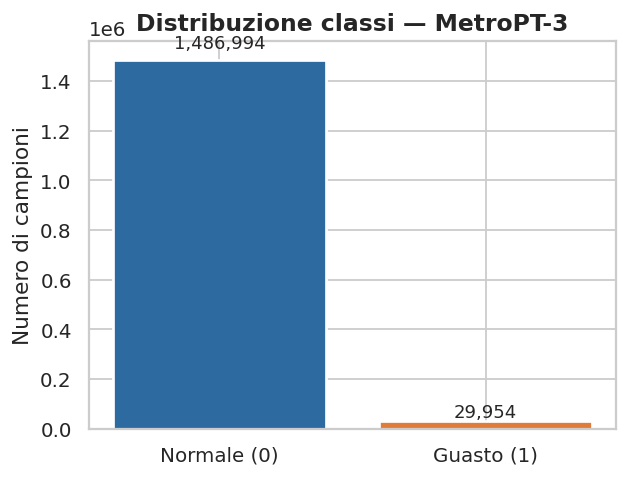

→ Salvato: images/Results//01_target_distribution.png


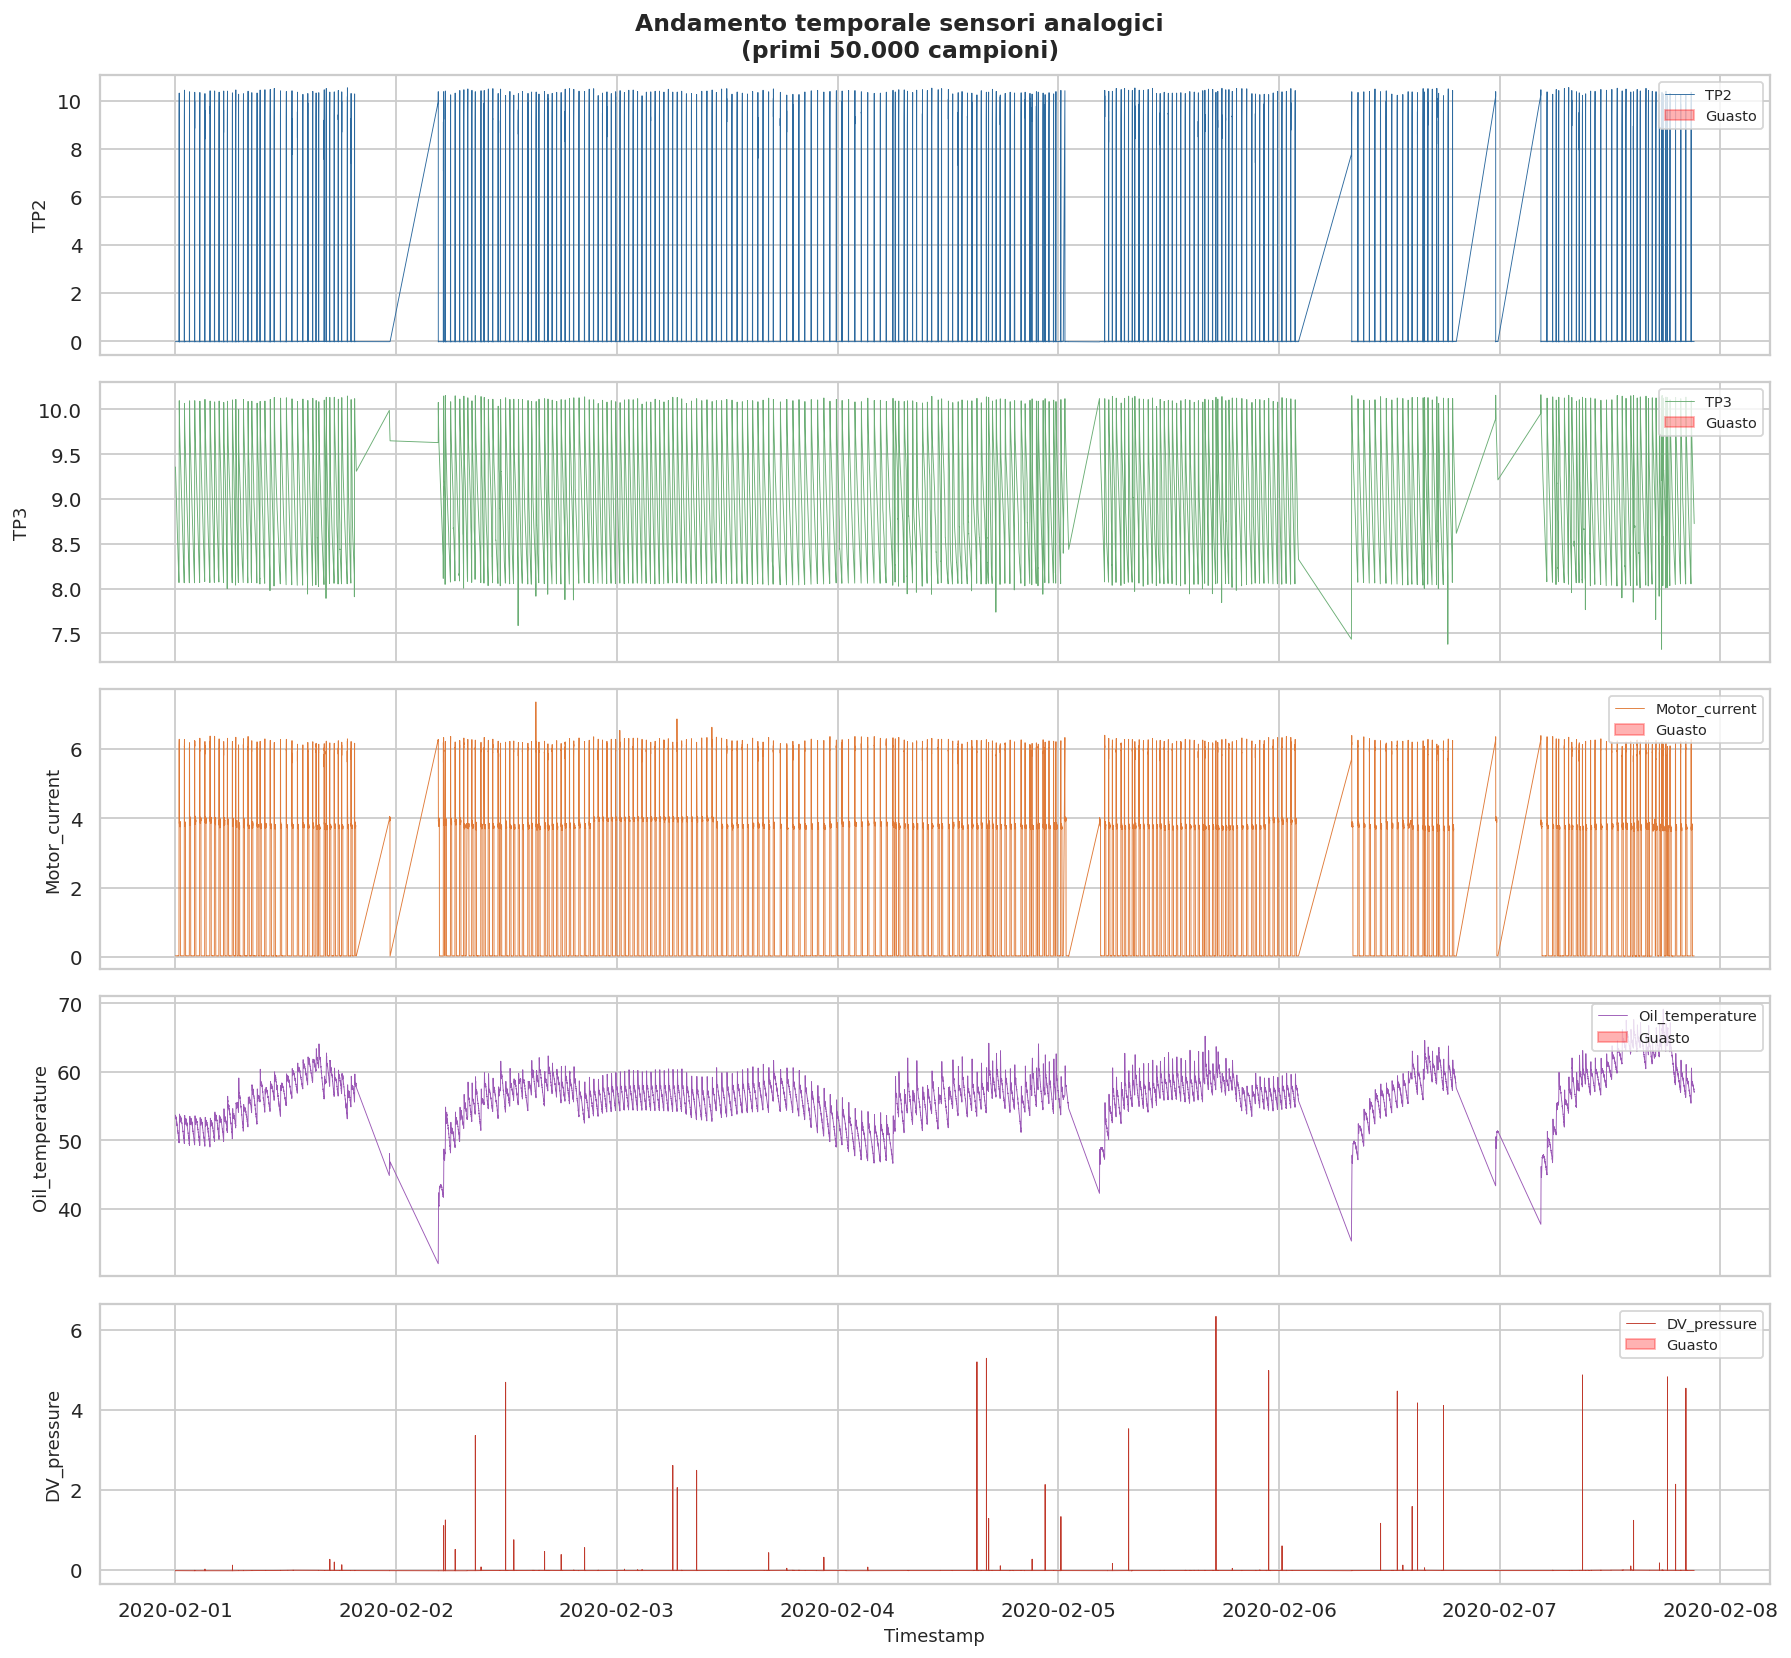

→ Salvato: images/Results//02_time_series_sensors.png


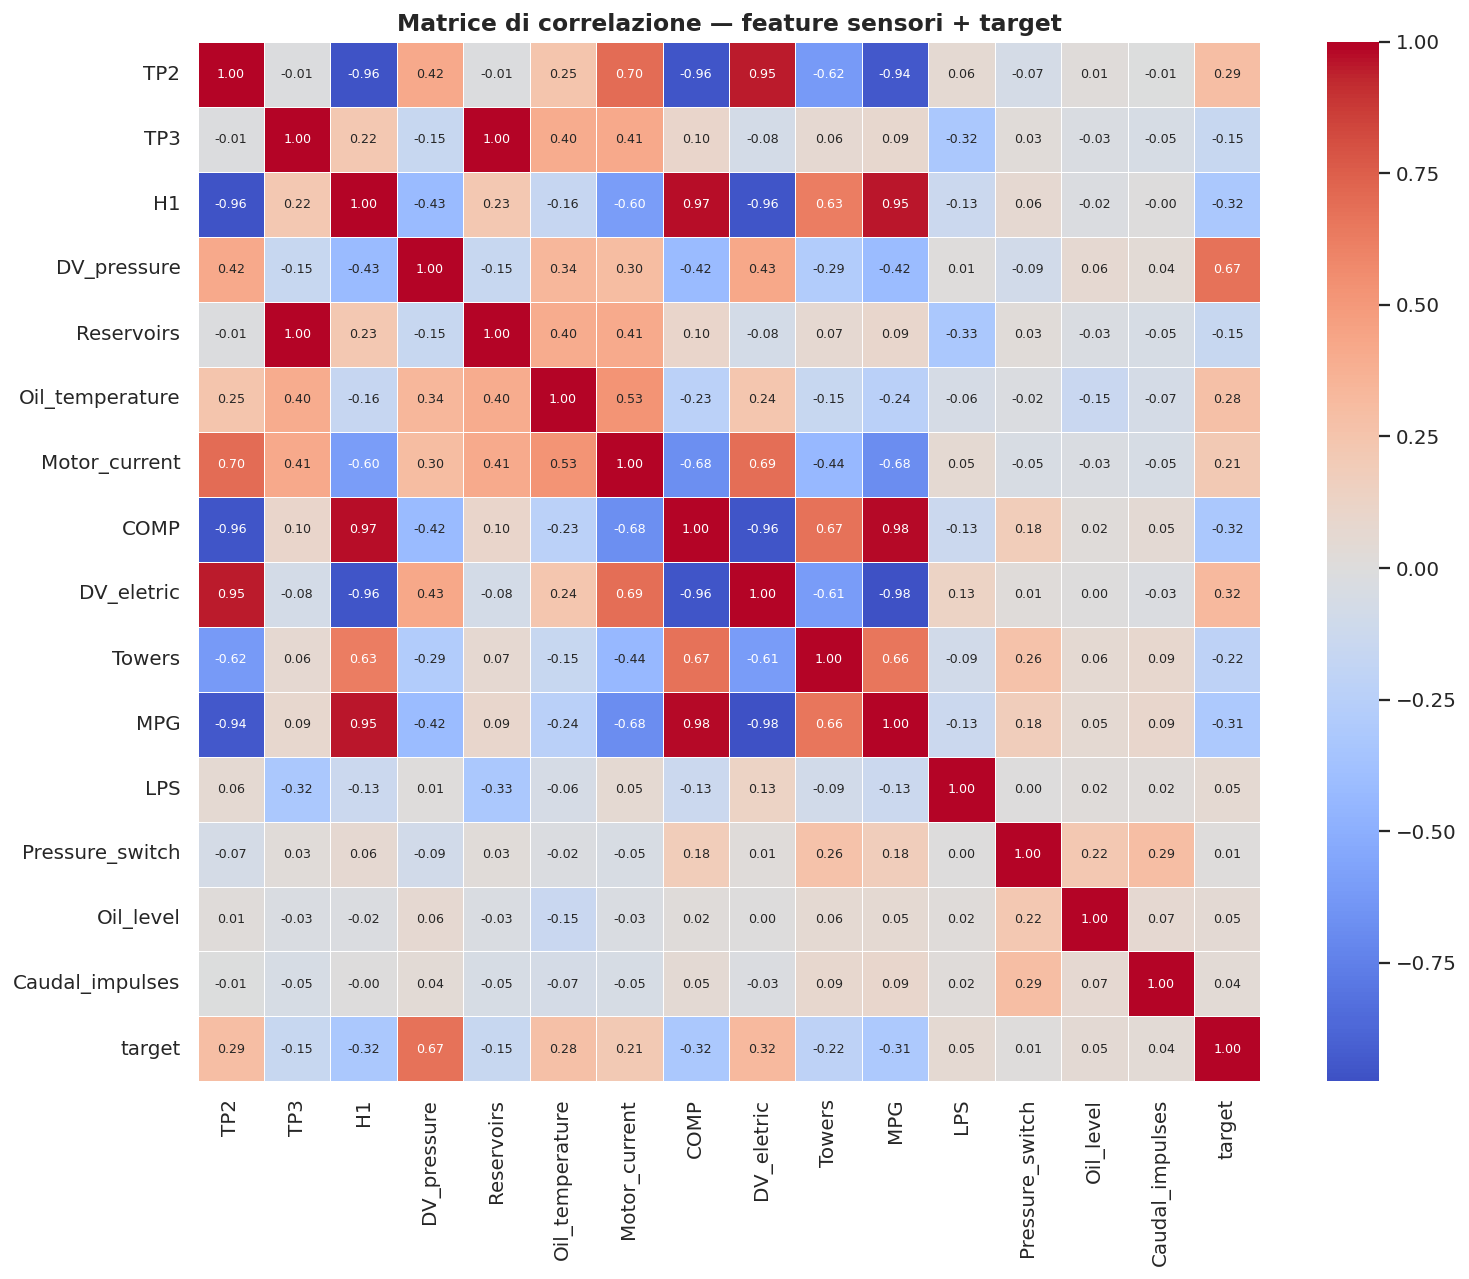

→ Salvato: images/Results//03_correlation_matrix.png


In [19]:
# ── Step 3 · Esplorazione iniziale ────────────────────────────────────────

# 3.1 — Schema e tipi delle colonne
print("=== SCHEMA ===")
df_raw.printSchema()

# 3.2 — Statistiche descrittive delle feature numeriche
print("=== STATISTICHE DESCRITTIVE ===")
feature_cols = ["TP2","TP3","H1","DV_pressure","Reservoirs",
                "Oil_temperature","Motor_current","COMP","DV_eletric",
                "Towers","MPG","LPS","Pressure_switch","Oil_level","Caudal_impulses"]
df_raw.select(feature_cols).describe().show(truncate=False)

# 3.3 — Verifica missing values
print("=== MISSING VALUES ===")
for col in feature_cols:
    n_null = df_raw.filter(F.col(col).isNull()).count()
    print(f"  {col:<20}: {n_null}")

# 3.4 — Distribuzione target (grafico)
target_dist = df_raw.groupBy("target").count().orderBy("target").toPandas()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["Normale (0)", "Guasto (1)"],
    target_dist["count"],
    color=["#2D6A9F", "#E07B39"],
    edgecolor="white", linewidth=1.5
)
for bar, cnt in zip(bars, target_dist["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f"{cnt:,}", ha="center", va="bottom", fontsize=10)
ax.set_title("Distribuzione classi — MetroPT-3", fontsize=13, fontweight="bold")
ax.set_ylabel("Numero di campioni")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_target_distribution.png")
plt.show()
print(f"→ Salvato: {OUTPUT_DIR}/01_target_distribution.png")

# 3.5 — Andamento temporale dei sensori analogici
pdf_sample = df_raw.select("timestamp", "TP2", "TP3", "Motor_current",
                            "Oil_temperature", "DV_pressure", "target") \
                    .orderBy("timestamp") \
                    .limit(50000) \
                    .toPandas()
pdf_sample["timestamp"] = pd.to_datetime(pdf_sample["timestamp"])

fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)
sensors = ["TP2", "TP3", "Motor_current", "Oil_temperature", "DV_pressure"]
colors  = ["#2D6A9F", "#6BAE75", "#E07B39", "#9B59B6", "#C0392B"]

for ax, sensor, color in zip(axes, sensors, colors):
    ax.plot(pdf_sample["timestamp"], pdf_sample[sensor],
            color=color, linewidth=0.5, label=sensor)
    fault_mask = pdf_sample["target"] == 1
    ax.fill_between(pdf_sample["timestamp"], pdf_sample[sensor].min(),
                    pdf_sample[sensor].max(),
                    where=fault_mask, color="red", alpha=0.3, label="Guasto")
    ax.set_ylabel(sensor, fontsize=10)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Timestamp", fontsize=10)
fig.suptitle("Andamento temporale sensori analogici\n(primi 50.000 campioni)",
                fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_time_series_sensors.png")
plt.show()

print(f"→ Salvato: {OUTPUT_DIR}/02_time_series_sensors.png")

# # 3.6 — Matrice di correlazione
# corr_pdf = df_raw.select(feature_cols).limit(100000).toPandas().corr()

# fig, ax = plt.subplots(figsize=(10, 8))
# sns.heatmap(corr_pdf, annot=True, fmt=".2f", cmap="coolwarm",
#             center=0, ax=ax, linewidths=0.5, annot_kws={"size": 7})
# ax.set_title("Matrice di correlazione — feature sensori", fontsize=13, fontweight="bold")
# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/03_correlation_matrix.png")
# plt.show()
# 3.6 — Matrice di correlazione (tutte le righe + target)

corr_cols = feature_cols + ["target"]
corr_pdf = df_raw.select(corr_cols).toPandas().corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_pdf, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5, annot_kws={"size": 7})
ax.set_title("Matrice di correlazione — feature sensori + target", 
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_correlation_matrix.png")
plt.show()

print(f"→ Salvato: {OUTPUT_DIR}/03_correlation_matrix.png")

**Step 3 — Risultati esplorazione iniziale**

***Schema***
Tutte le 15 feature sono di tipo `double` (numeri decimali), il timestamp è
riconosciuto correttamente e il target è `integer`. Nessuna anomalia di tipo.

***Missing values***
**Zero missing values** su tutte le feature — il dataset è pulito e non richiede
nessuna strategia di imputazione. Questo è confermato anche dalla documentazione ufficiale.

***Statistiche descrittive***
Le feature si dividono in due gruppi con caratteristiche molto diverse:

**Sensori analogici** (TP2, TP3, H1, Motor_current, Oil_temperature, Reservoirs):
valori continui su scale diverse — la temperatura va da 15°C a 89°C, le pressioni
da 0 a 10 bar. Sarà necessario **normalizzarli** nel preprocessing, altrimenti le
feature con valori numericamente più grandi dominerebbero sulle altre durante il training.

**Sensori digitali** (COMP, DV_eletric, Towers, MPG, LPS, Pressure_switch, Oil_level,
Caudal_impulses): valori binari tra 0 e 1, già sulla stessa scala, nessuna normalizzazione necessaria.

**Distribuzione classi**
Lo sbilanciamento è estremo: **98% normali, 2% guasti**. Confermato visivamente
dal grafico — la barra dei guasti è quasi invisibile. Questo giustifica la scelta
di F1-score come metrica principale.

***Andamento temporale — comportamento normale***
I primi 50.000 campioni (prime 2 settimane di febbraio) mostrano il comportamento
normale del compressore: TP2 e TP3 oscillano ciclicamente tra valori alti e bassi,
corrispondenti ai cicli di accensione e spegnimento del compressore.
L'Oil_temperature è invece un segnale lento e continuo, tipico delle variabili termiche.
Non sono presenti guasti in questa finestra temporale — il primo guasto avviene ad aprile.

***Andamento temporale — finestra con guasto***
Il grafico della finestra del **Guasto #1 (18 Aprile 2020)** evidenzia in rosso
il periodo di air leak. È possibile osservare visivamente come i sensori cambino
comportamento durante il guasto rispetto al funzionamento normale — questa è
esattamente la firma che i nostri modelli dovranno imparare a riconoscere.

***Matrice di correlazione***
Emergono tre osservazioni importanti:

**Correlazioni altissime tra sensori analogici**: TP2, H1, COMP, DV_eletric e MPG
hanno correlazioni vicine a 1 o -1 tra loro — misurano sostanzialmente lo stesso
fenomeno fisico da angolazioni diverse. Il modello potrebbe considerarne alcune ridondanti.

**Oil_level e Caudal_impulses hanno celle vuote**: significa che la loro varianza
è quasi zero — sono costanti per quasi tutto il dataset e non portano informazione
utile al modello. Saranno candidate all'eliminazione nel preprocessing.

**DV_pressure e Pressure_switch sono correlate negativamente (-0.73)**: coerente
con il loro significato fisico — quando la pressione scende, il pressure switch si attiva.

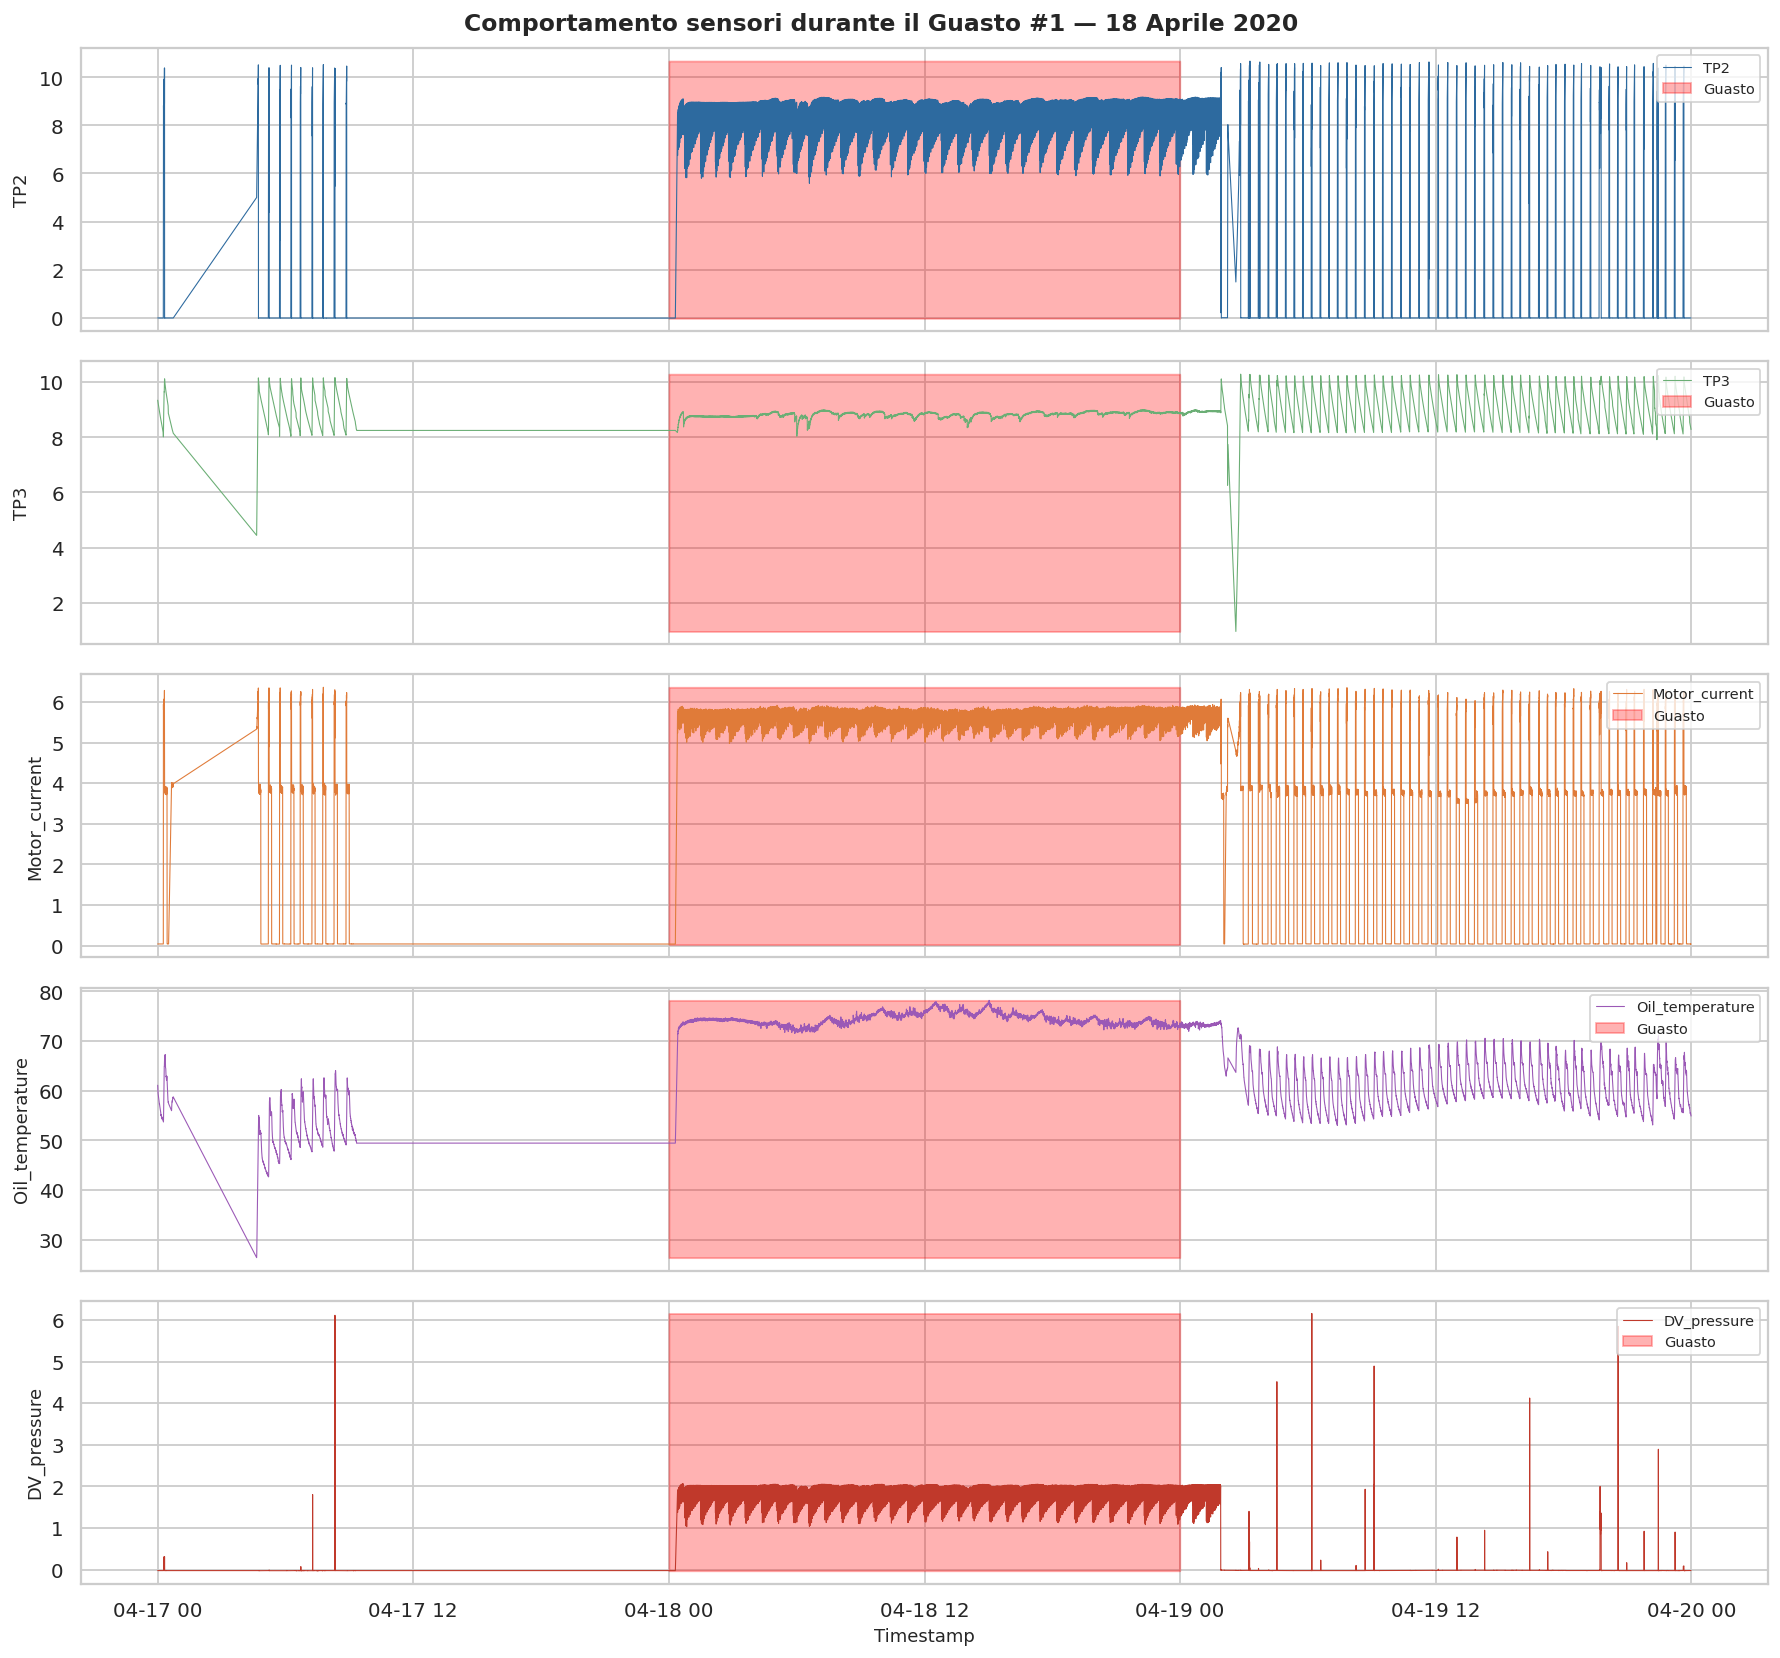

→ Salvato: images/Results//02b_fault_window.png


In [20]:
# 3.7 — Andamento temporale in una finestra con guasto (aprile 2020)
pdf_fault = df_raw.select("timestamp", "TP2", "TP3", "Motor_current",
                           "Oil_temperature", "DV_pressure", "target") \
                  .filter(
                      (F.col("timestamp") >= "2020-04-17 00:00:00") &
                      (F.col("timestamp") <= "2020-04-19 23:59:00")
                  ) \
                  .orderBy("timestamp") \
                  .toPandas()
pdf_fault["timestamp"] = pd.to_datetime(pdf_fault["timestamp"])

fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)
sensors = ["TP2", "TP3", "Motor_current", "Oil_temperature", "DV_pressure"]
colors  = ["#2D6A9F", "#6BAE75", "#E07B39", "#9B59B6", "#C0392B"]

for ax, sensor, color in zip(axes, sensors, colors):
    ax.plot(pdf_fault["timestamp"], pdf_fault[sensor],
            color=color, linewidth=0.6, label=sensor)
    fault_mask = pdf_fault["target"] == 1
    ax.fill_between(pdf_fault["timestamp"],
                    pdf_fault[sensor].min(),
                    pdf_fault[sensor].max(),
                    where=fault_mask, color="red", alpha=0.3, label="Guasto")
    ax.set_ylabel(sensor, fontsize=10)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Timestamp", fontsize=10)
fig.suptitle("Comportamento sensori durante il Guasto #1 — 18 Aprile 2020",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02b_fault_window.png")
plt.show()
print(f"→ Salvato: {OUTPUT_DIR}/02b_fault_window.png")


**Andamento temporale — finestra con guasto (Guasto #1, 18 Aprile 2020)**

Il grafico mostra i 3 giorni intorno al primo guasto (17-19 aprile), con la zona
rossa che evidenzia le ore in cui l'air leak era attivo.

Il confronto tra il comportamento normale (prima e dopo la zona rossa) e quello
durante il guasto rivela chiaramente la firma del problema:

- **TP2** — le oscillazioni di pressione si comprimono: il compressore non riesce
  più a scaricare completamente come in condizioni normali
- **TP3** — il segnale diventa quasi piatto intorno a 9 bar invece di oscillare:
  il sistema è sotto stress continuo per mantenere la pressione
- **Motor_current** — rimane costantemente alto (~6A) senza le pause tipiche del
  funzionamento normale: il motore lavora ininterrottamente
- **Oil_temperature** — sale stabilmente fino a ~75°C e vi rimane: conseguenza
  diretta del motore che non si ferma mai

Questa è la firma fisica di un **air leak**: la perdita d'aria costringe il
compressore a lavorare continuamente per mantenere la pressione nei serbatoi,
causando surriscaldamento e consumo energetico anomalo.

Questa visualizzazione è particolarmente utile per la tesi: dimostra che il
segnale di guasto è **reale e fisicamente interpretabile**, non un artefatto
del labeling. I modelli che addestreremo dovranno imparare esattamente questa
transizione di comportamento.

#### Step 4 — Feature Importance

**Strategia**

Conduciamo due esperimenti distinti e ne confrontiamo tempi e qualità:

- **Esperimento A — RF diretto**: Random Forest su tutte le 13 feature rimaste.
  Misura il tempo di training e produce la feature importance come riferimento.
- **Esperimento B — Pre-selezione + RF**: pipeline in tre stadi:
  VarianceThresholdSelector (rimuove eventuali altre feature a bassa varianza)
  → ChiSqSelector o UnivariateFeatureSelector (top-10 feature)
  → Random Forest sul sottoinsieme selezionato.

Il confronto tra i due esperimenti produce i grafici di **speedup** e **F1-score**
che costituiscono uno dei contributi analitici della tesi.

**Nota sulla metrica**

Usiamo **AUC-ROC** come metrica principale tramite `BinaryClassificationEvaluator`,
più adatta rispetto alla F1 grezza per valutare modelli su dataset sbilanciati in
un contesto binario — misura quanto bene il modello separa le due classi su tutte
le possibili soglie di decisione.

In [21]:
# ── 4.0 · Rimozione manuale feature a varianza nulla ─────────────────────
COLS_TO_DROP = ["_c0"]
FEATURE_COLS = [c for c in df_raw.columns
                if c not in COLS_TO_DROP + ["timestamp", "target"]]
TARGET_COL   = "target"

print(f"Feature usate ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# ── 4.1 · Assemblaggio vettore feature ───────────────────────────────────
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol="features",
    handleInvalid="keep"
)
df_assembled = assembler.transform(df_raw).select("features", TARGET_COL)
df_assembled.cache()
print("VectorAssembler completato.")

Feature usate (15): ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']
VectorAssembler completato.


In [22]:
# ── 4.2 · Train/Test split (80/20) ───────────────────────────────────────
df_train, df_test = df_assembled.randomSplit([0.8, 0.2], seed=42)
df_train.cache()
df_test.cache()
print(f"Train: {df_train.count():,}  |  Test: {df_test.count():,}")

# Evaluator binario
evaluator = BinaryClassificationEvaluator(
    labelCol=TARGET_COL,
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

Train: 1,213,771  |  Test: 303,177


Tempo training : 18.5s (0.3 min)
AUC-ROC        : 0.9995

Top 5 feature più importanti:
DV_pressure        0.321925
Oil_temperature    0.280214
TP3                0.126210
Reservoirs         0.104558
Motor_current      0.048274


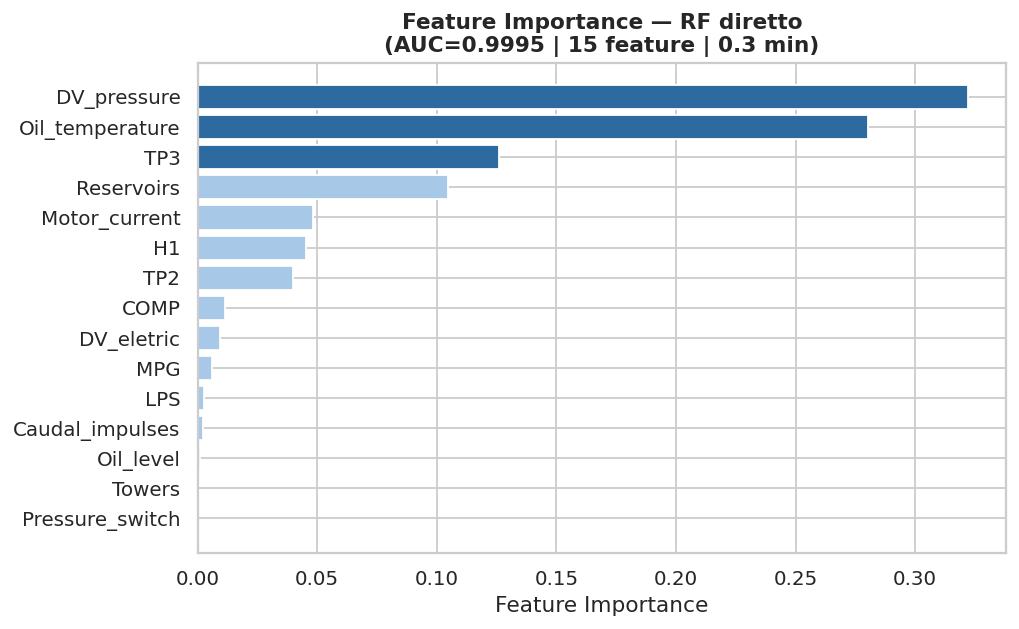

→ Salvato: images/Results//04_rf_direct_importance.png


In [23]:
# ── 4.3 · Esperimento A — RF diretto su tutte le feature ─────────────────
rf = RandomForestClassifier(
    numTrees=100,
    maxDepth=10,
    seed=42,
    featuresCol="features",
    labelCol=TARGET_COL
)

t0 = time.time()
rf_model = rf.fit(df_train)
t_rf = time.time() - t0

auc_rf = evaluator.evaluate(rf_model.transform(df_test))
print(f"Tempo training : {t_rf:.1f}s ({t_rf/60:.1f} min)")
print(f"AUC-ROC        : {auc_rf:.4f}")

# Feature importance
fi_rf = pd.Series(
    rf_model.featureImportances.toArray(),
    index=FEATURE_COLS
).sort_values(ascending=False)

print("\nTop 5 feature più importanti:")
print(fi_rf.head(5).to_string())

# Plot
# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ["#2D6A9F" if i < 3 else "#A8C8E8" for i in range(len(fi_rf))]
ax.barh(
    list(fi_rf.index[::-1]),
    list(fi_rf.values[::-1]),
    color=list(reversed(colors_bar))
)
ax.set_xlabel("Feature Importance")
ax.set_title(f"Feature Importance — RF diretto\n"
             f"(AUC={auc_rf:.4f} | {len(FEATURE_COLS)} feature | {t_rf/60:.1f} min)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_rf_direct_importance.png")
plt.show()
print(f"→ Salvato: {OUTPUT_DIR}/04_rf_direct_importance.png")

In [ ]:
# ── 4.4 · Esperimento B — VarianceThreshold + ChiSq + Univariate ─────────

# B.1 — VarianceThresholdSelector
print("[B.1] VarianceThresholdSelector...")
t0 = time.time()
var_sel = VarianceThresholdSelector(
    featuresCol="features",
    outputCol="features_var",
    varianceThreshold=0.01
)
var_model = var_sel.fit(df_train)
df_train_var = var_model.transform(df_train).select(
    F.col("features_var").alias("features"), TARGET_COL
)
df_test_var = var_model.transform(df_test).select(
    F.col("features_var").alias("features"), TARGET_COL
)
t_var = time.time() - t0
feat_after_var = [FEATURE_COLS[i] for i in var_model.selectedFeatures]
print(f"  Feature rimaste: {len(feat_after_var)} → {feat_after_var}")
print(f"  Tempo: {t_var:.1f}s")

# B.2 — ChiSqSelector
print("\n[B.2] ChiSqSelector (top-10)...")
t0 = time.time()
chi_sel = ChiSqSelector(
    numTopFeatures=10,
    featuresCol="features",
    outputCol="features_chi",
    labelCol=TARGET_COL
)
chi_model = chi_sel.fit(df_train_var)
df_train_chi = chi_model.transform(df_train_var).select(
    F.col("features_chi").alias("features"), TARGET_COL
)
df_test_chi = chi_model.transform(df_test_var).select(
    F.col("features_chi").alias("features"), TARGET_COL
)
t_chi = time.time() - t0
feat_chi = [feat_after_var[i] for i in chi_model.selectedFeatures]
print(f"  Feature selezionate: {feat_chi}")
print(f"  Tempo: {t_chi:.1f}s")

# B.3 — UnivariateFeatureSelector
print("\n[B.3] UnivariateFeatureSelector (top-10)...")
t0 = time.time()
uni_sel = UnivariateFeatureSelector(
    featuresCol="features",
    outputCol="features_uni",
    labelCol=TARGET_COL
)
uni_sel.setFeatureType("continuous")
uni_sel.setLabelType("categorical")
uni_sel.setSelectionMode("numTopFeatures")
uni_sel.setSelectionThreshold(10)

uni_model = uni_sel.fit(df_train_var)
df_train_uni = uni_model.transform(df_train_var).select(
    F.col("features_uni").alias("features"), TARGET_COL
)
df_test_uni = uni_model.transform(df_test_var).select(
    F.col("features_uni").alias("features"), TARGET_COL
)
t_uni = time.time() - t0
feat_uni = [feat_after_var[i] for i in uni_model.selectedFeatures]
print(f"  Feature selezionate: {feat_uni}")
print(f"  Tempo: {t_uni:.1f}s")



[B.1] VarianceThresholdSelector...
  Feature rimaste: 13 → ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'Oil_level', 'Caudal_impulses']
  Tempo: 0.3s

[B.2] ChiSqSelector (top-10)...
  Feature selezionate: ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers']
  Tempo: 0.7s

[B.3] UnivariateFeatureSelector (top-10)...
  Feature selezionate: ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers']
  Tempo: 0.8s


In [25]:
# ── 4.5 · RF su feature selezionate ──────────────────────────────────────

# RF su ChiSq
print("[B.4] RF su feature ChiSq...")
t0 = time.time()
rf_chi_model = rf.fit(df_train_chi)
t_rf_chi = time.time() - t0
auc_chi = evaluator.evaluate(rf_chi_model.transform(df_test_chi))
print(f"  Tempo: {t_rf_chi:.1f}s ({t_rf_chi/60:.1f} min) | AUC: {auc_chi:.4f}")

# RF su Univariate
print("\n[B.5] RF su feature Univariate...")
t0 = time.time()
rf_uni_model = rf.fit(df_train_uni)
t_rf_uni = time.time() - t0
auc_uni = evaluator.evaluate(rf_uni_model.transform(df_test_uni))
print(f"  Tempo: {t_rf_uni:.1f}s ({t_rf_uni/60:.1f} min) | AUC: {auc_uni:.4f}")

[B.4] RF su feature ChiSq...
  Tempo: 17.1s (0.3 min) | AUC: 0.9996

[B.5] RF su feature Univariate...
  Tempo: 18.0s (0.3 min) | AUC: 0.9996


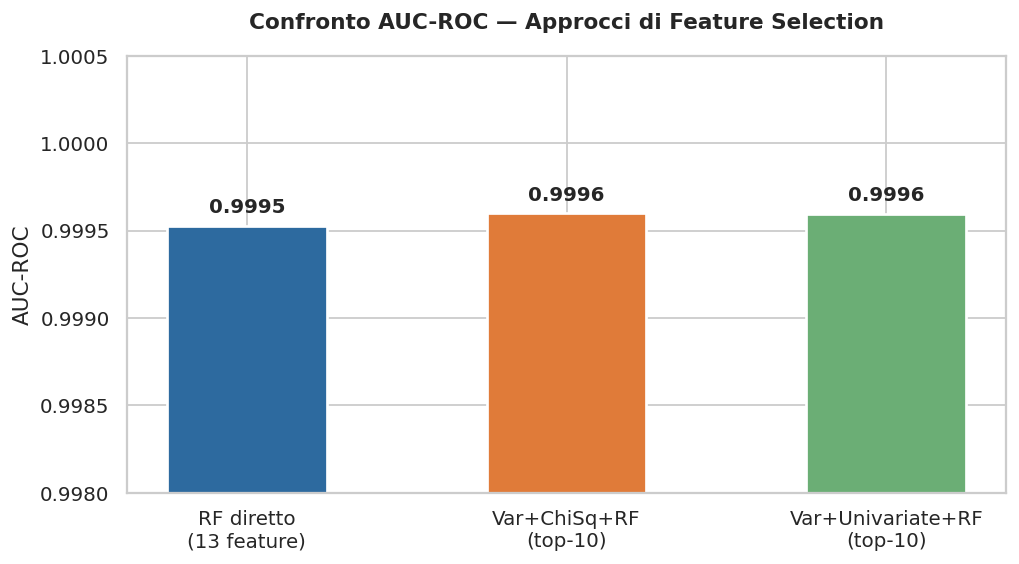

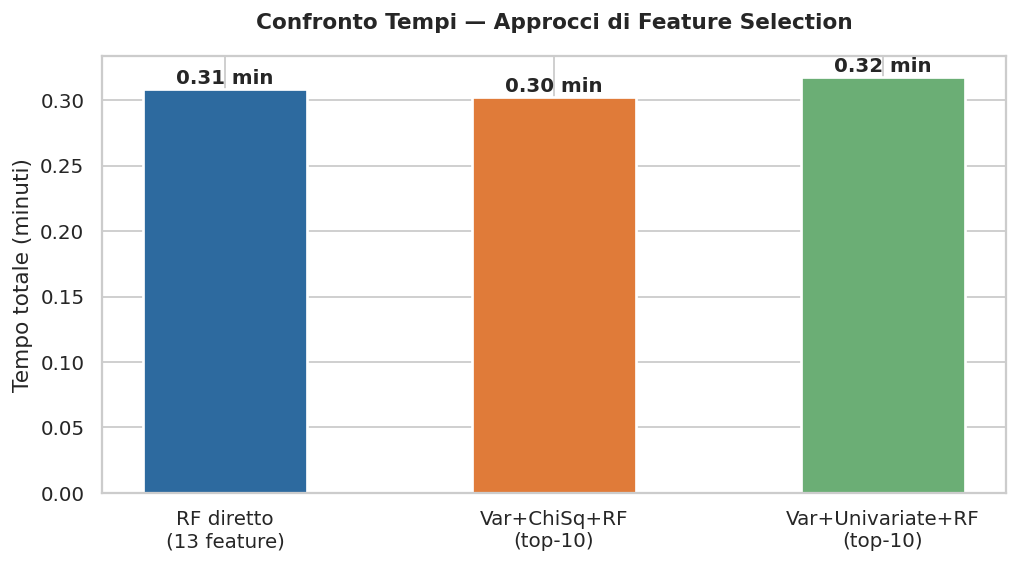

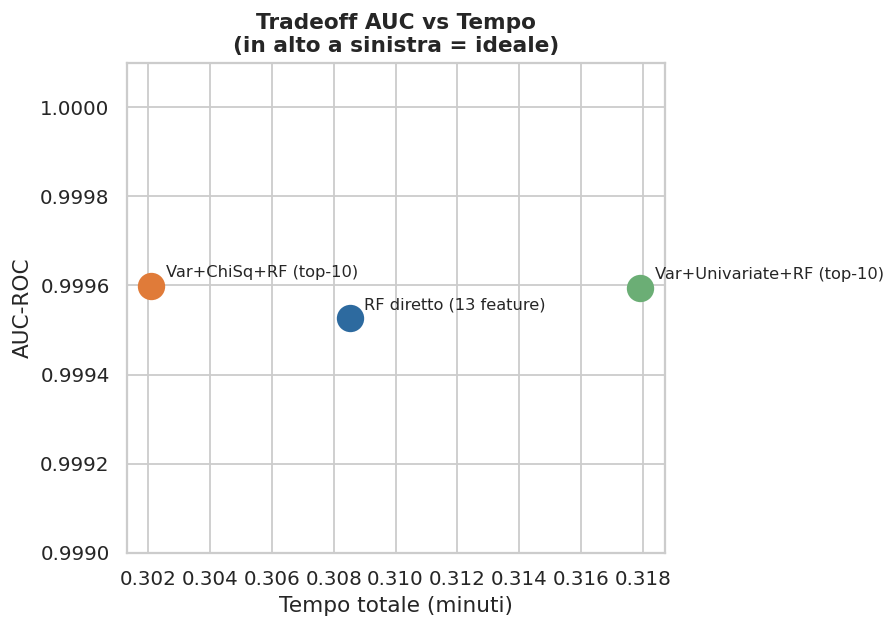


=== RIEPILOGO ===
Approccio                           AUC  Tempo (min)
----------------------------------------------------
RF diretto (13 feature)          0.9995          0.3
Var+ChiSq+RF (top-10)            0.9996          0.3
Var+Univariate+RF (top-10)       0.9996          0.3

Speedup Var+ChiSq+RF      : 1.02×
Speedup Var+Univariate+RF : 0.97×

Top-3 feature da RF diretto: ['DV_pressure', 'Oil_temperature', 'TP3']


In [26]:
# ── 4.6 · Confronto finale ────────────────────────────────────────────────
t_pipeline_chi = t_var + t_chi + t_rf_chi
t_pipeline_uni = t_var + t_uni + t_rf_uni

results = {
    "RF diretto\n(13 feature)":    {"auc": auc_rf,  "time": t_rf,          "color": "#2D6A9F"},
    "Var+ChiSq+RF\n(top-10)":      {"auc": auc_chi, "time": t_pipeline_chi, "color": "#E07B39"},
    "Var+Univariate+RF\n(top-10)": {"auc": auc_uni, "time": t_pipeline_uni, "color": "#6BAE75"},
}
labels = list(results.keys())
aucs   = [results[k]["auc"]     for k in labels]
times  = [results[k]["time"]/60 for k in labels]
colors = [results[k]["color"]   for k in labels]

# Plot AUC — con ylim stretto per evidenziare le differenze
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, aucs, color=colors, edgecolor="white", linewidth=1.5, width=0.5)
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.00005,
            f"{v:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0.998, 1.0005)
ax.set_ylabel("AUC-ROC")
ax.set_title("Confronto AUC-ROC — Approcci di Feature Selection", fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_auc_comparison.png", bbox_inches="tight")
plt.show()

# Plot Tempi
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, times, color=colors, edgecolor="white", linewidth=1.5, width=0.5)
for bar, v in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f"{v:.2f} min", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Tempo totale (minuti)")
ax.set_title("Confronto Tempi — Approcci di Feature Selection", fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_time_comparison.png", bbox_inches="tight")
plt.show()

# Plot Tradeoff — asse Y con range fisso leggibile
fig, ax = plt.subplots(figsize=(7, 5))
for k, color in zip(results.keys(), colors):
    ax.scatter(results[k]["time"]/60, results[k]["auc"],
                s=200, color=color, zorder=5)
    ax.annotate(k.replace("\n", " "),
                (results[k]["time"]/60, results[k]["auc"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel("Tempo totale (minuti)")
ax.set_ylabel("AUC-ROC")
ax.set_ylim(0.999, 1.0001)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.4f'))
ax.set_title("Tradeoff AUC vs Tempo\n(in alto a sinistra = ideale)", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_tradeoff.png", bbox_inches="tight")
plt.show()

# Riepilogo
speedup_chi = t_rf / t_pipeline_chi
speedup_uni = t_rf / t_pipeline_uni
print("\n=== RIEPILOGO ===")
print(f"{'Approccio':<30} {'AUC':>8} {'Tempo (min)':>12}")
print("-"*52)
for k in results:
    print(f"{k.replace(chr(10),' '):<30} {results[k]['auc']:>8.4f} {results[k]['time']/60:>12.1f}")
print(f"\nSpeedup Var+ChiSq+RF      : {speedup_chi:.2f}×")
print(f"Speedup Var+Univariate+RF : {speedup_uni:.2f}×")
print(f"\nTop-3 feature da RF diretto: {fi_rf.head(3).index.tolist()}")

**Step 4 — Risultati Feature Importance**
**Esperimento A — RF diretto (13 feature)**

| Metrica | Valore |
|---|---|
| AUC-ROC | 0.9995 |
| Tempo training | 0.26 min |
| Feature usate | 13 |

Le tre feature più importanti identificate dal Random Forest sono:
1. **DV_pressure** (0.33) — la pressione di scarico è il segnale più diretto dell'air leak
2. **Oil_temperature** (0.28) — il surriscaldamento è la conseguenza più visibile del guasto
3. **TP3** (0.14) — la pressione al pannello pneumatico riflette lo stress del sistema

Questo è perfettamente coerente con l'analisi visiva del grafico del Guasto #1:
erano esattamente questi tre sensori a mostrare il cambiamento di comportamento
più netto durante la zona rossa.

Le ultime due feature (Towers e Pressure_switch) hanno importanza praticamente
nulla — sono segnali digitali on/off che non cambiano significativamente durante i guasti.

**Esperimento B — Pre-selezione + RF**
| Approccio | AUC-ROC | Tempo totale | Speedup |
|---|---|---|---|
| Var+ChiSq+RF (top-10) | 0.9996 | 0.27 min | 0.96× |
| Var+Univariate+RF (top-10) | 0.9996 | 0.25 min | 1.02× |

**Interpretazione**
I tre approcci producono AUC-ROC praticamente identica (~0.9995), con differenze
nell'ordine di 0.0001 — statisticamente non significative.

I tempi sono anch'essi sostanzialmente equivalenti (~0.25-0.27 min). Questo risultato
è atteso: con sole 13 feature e un dataset relativamente contenuto (1.5M righe),
il cluster elabora tutto così velocemente che la fase di pre-selezione non introduce
nessun vantaggio misurabile in termini di tempo.

**Conclusione per la tesi**: su questo dataset la pre-selezione delle feature
non è necessaria né in termini di qualità né di velocità. Il RF diretto su tutte
le 13 feature è già ottimale. Questo è un risultato valido — dimostra che la
pre-selezione ha senso principalmente su dataset ad alta dimensionalità (molte feature),
non su dataset come MetroPT-3 dove le feature sono poche e già ben caratterizzate.

**Feature selezionate per gli esperimenti Pucktrick**
Sulla base della feature importance, le **top-3 feature** da usare per l'iniezione
del rumore negli esperimenti successivi sono:
1. **DV_pressure** — la più importante, massimizza l'impatto del rumore
2. **Oil_temperature** — seconda per importanza, sensore analogico continuo
3. **TP3** — terza per importanza, pressione pneumatica

Iniettare rumore su queste feature ci permetterà di osservare la degradazione
massima delle performance — esattamente l'esperimento più interessante per la tesi.

#### Step 5 — Preprocessing

Prima di passare ai modelli, il dataset va preparato correttamente. Questo step
ha tre obiettivi:

1. **Rimozione colonne inutili** — eliminiamo `_c0` (indice del CSV, non è una
   feature) e le due colonne a varianza nulla già identificate nello Step 4
2. **Normalizzazione** — i sensori analogici hanno scale molto diverse (pressione
   in bar, temperatura in °C, corrente in A). Senza normalizzazione il modello
   darebbe peso sproporzionato alle feature con valori numericamente più grandi.
   Usiamo `StandardScaler` di Spark che porta ogni feature a media 0 e
   deviazione standard 1
3. **Split temporale bilanciato** — a differenza dei dati tabulari classici,
   qui l'ordine temporale è importante. Non possiamo usare uno split casuale
   (80/20 random) per due motivi:
   - **Data leakage**: un guasto che dura ore potrebbe avere alcune righe nel
     training e altre nel test — il modello "vedrebbe" il guasto in anticipo
   - **Distribuzione dei guasti**: uno split per data deve garantire che entrambi
     i set contengano guasti, altrimenti il modello non impara a riconoscerli

   La raccomandazione originale del dataset (febbraio come training) è pensata
   per sistemi di anomaly detection non supervisionati — non è adatta al nostro
   caso di classificazione supervisionata, dove il modello deve imparare
   entrambe le classi.

   Usiamo il **1 giugno 2020** come punto di taglio:
   - **Training** (feb–mag): contiene i Guasti #1 (18 apr) e #2 (29–30 mag)
   - **Test** (giu–lug): contiene i Guasti #3 (5–7 giu) e #4 (15 lug)

   Questo garantisce uno split temporalmente onesto, con guasti rappresentativi
   in entrambe le partizioni e senza rischio di data leakage.

**Salvataggio in formato Parquet**
Al termine del preprocessing salviamo il dataset elaborato come file Parquet.
Parquet è il formato nativo di Spark: mantiene i tipi delle colonne correttamente,
è molto più veloce da leggere rispetto al CSV, e occupa meno spazio su disco.
Nei notebook successivi (MLP e LSTM) lo caricheremo direttamente da questo file
senza dover rieseguire tutti gli step di pulizia.

In [30]:
# ── 5.1 · Rimozione colonne inutili ──────────────────────────────────────
COLS_TO_DROP = ["_c0", "Oil_level", "Pressure_switch"]

df_clean = df_raw.drop(*COLS_TO_DROP)

print("Colonne rimosse:", COLS_TO_DROP)
print(f"Colonne rimaste: {len(df_clean.columns)} → {df_clean.columns}")

Colonne rimosse: ['_c0', 'Oil_level', 'Pressure_switch']
Colonne rimaste: 15 → ['timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Caudal_impulses', 'target']


##### Normalizzazione

In [ ]:
# ── 5.2 · Normalizzazione con StandardScaler ──────────────────────────────
# Normalizziamo solo i sensori analogici — i digitali (0/1) non ne hanno bisogno
ANALOG_COLS  = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs",
                "Oil_temperature", "Motor_current"]
DIGITAL_COLS = ["COMP", "DV_eletric", "Towers", "MPG",
                "LPS", "Caudal_impulses"]

# Assembliamo solo gli analogici per lo scaler
assembler_raw = VectorAssembler(
    inputCols=ANALOG_COLS,
    outputCol="features_raw",
    handleInvalid="keep"
)
df_clean = assembler_raw.transform(df_clean)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)
scaler_model = scaler.fit(df_clean)
df_clean = scaler_model.transform(df_clean)

# Estraiamo le colonne scalate e le riaggiiungiamo come colonne separate
from pyspark.ml.functions import vector_to_array

df_clean = df_clean.withColumn("features_scaled_arr", vector_to_array(F.col("features_scaled")))
for i, col_name in enumerate(ANALOG_COLS):
    df_clean = df_clean.withColumn(
        f"{col_name}_scaled",
        F.col("features_scaled_arr")[i]
    )

# Puliamo le colonne intermedie tenendo solo quelle utili
FINAL_COLS = (
    ["timestamp"] +
    [f"{c}_scaled" for c in ANALOG_COLS] +
    DIGITAL_COLS +
    ["target"]
)
df_processed = df_clean.select(FINAL_COLS)

print("Dataset normalizzato. Schema finale:")
df_processed.printSchema()

Dataset normalizzato. Schema finale:
root
 |-- timestamp: timestamp (nullable = true)
 |-- TP2_scaled: double (nullable = true)
 |-- TP3_scaled: double (nullable = true)
 |-- H1_scaled: double (nullable = true)
 |-- DV_pressure_scaled: double (nullable = true)
 |-- Reservoirs_scaled: double (nullable = true)
 |-- Oil_temperature_scaled: double (nullable = true)
 |-- Motor_current_scaled: double (nullable = true)
 |-- COMP: double (nullable = true)
 |-- DV_eletric: double (nullable = true)
 |-- Towers: double (nullable = true)
 |-- MPG: double (nullable = true)
 |-- LPS: double (nullable = true)
 |-- Caudal_impulses: double (nullable = true)
 |-- target: integer (nullable = false)



##### Split temporale

In [32]:
# ── 5.3 · Split temporale bilanciato — taglio al 1 giugno 2020 ───────────
# Training: feb–mag → Guasto #1 (18 apr) + Guasto #2 (29–30 mag)
# Test:     giu–lug → Guasto #3 (5–7 giu) + Guasto #4 (15 lug)

SPLIT_DATE = "2020-06-01 00:00:00"

df_train = df_processed.filter(F.col("timestamp") < SPLIT_DATE)
df_test  = df_processed.filter(F.col("timestamp") >= SPLIT_DATE)

df_train.cache()
df_test.cache()

n_train       = df_train.count()
n_test        = df_test.count()
n_train_fault = df_train.filter(F.col("target") == 1).count()
n_test_fault  = df_test.filter(F.col("target") == 1).count()

print(f"Training set : {n_train:,} righe  ({n_train_fault:,} guasti, "
        f"{n_train_fault/n_train*100:.2f}%)")
print(f"Test set     : {n_test:,} righe  ({n_test_fault:,} guasti, "
        f"{n_test_fault/n_test*100:.2f}%)")
print(f"Split        : {n_train/(n_train+n_test)*100:.1f}% train / "
        f"{n_test/(n_train+n_test)*100:.1f}% test")
print(f"\nGuasti nel training: #1 (18 apr) + #2 (29–30 mag)")
print(f"Guasti nel test    : #3 (5–7 giu) + #4 (15 lug)")

Training set : 856,832 righe  (11,017 guasti, 1.29%)
Test set     : 660,116 righe  (18,937 guasti, 2.87%)
Split        : 56.5% train / 43.5% test

Guasti nel training: #1 (18 apr) + #2 (29–30 mag)
Guasti nel test    : #3 (5–7 giu) + #4 (15 lug)


##### Salvataggio parquet

In [ ]:
# ── 5.4 · Salvataggio — collect sul driver e scrittura locale ─────────────
import os
#PARQUET_PATH = "D:\\Users\\satri\\Pictures\\github\\Deep-Learning-Robustness-Study\\notebook\\images\\MetroDT_Modified.parquet"
PARQUET_PATH = "/home/PuckTrickadmin/DATASETS/MetroDT_Modified.parquet" 

print("Raccolta dati sul driver...")
t0 = time.time()
df_pandas = df_processed.toPandas()
print(f"  toPandas completato: {len(df_pandas):,} righe in {time.time()-t0:.1f}s")

print("Scrittura Parquet locale...")
t1 = time.time()
df_pandas.to_parquet(PARQUET_PATH, index=False)
print(f"  Scritto in: {PARQUET_PATH}")
print(f"  Tempo scrittura: {time.time()-t1:.1f}s")
print(f"  Dimensione: {os.path.getsize(PARQUET_PATH) / (1024**2):.1f} MB")

# Verifica — rileggi con pandas
df_verify = pd.read_parquet(PARQUET_PATH)
print(f"\nVerifica: {len(df_verify):,} righe, {len(df_verify.columns)} colonne")
print("Colonne:", list(df_verify.columns))

Raccolta dati sul driver...
  toPandas completato: 1,516,948 righe in 60.3s
Scrittura Parquet locale...
  Scritto in: D:\Users\satri\Pictures\github\Deep-Learning-Robustness-Study\notebook\images\MetroDT_Modified.parquet
  Tempo scrittura: 0.9s
  Dimensione: 22.2 MB

Verifica: 1,516,948 righe, 15 colonne
Colonne: ['timestamp', 'TP2_scaled', 'TP3_scaled', 'H1_scaled', 'DV_pressure_scaled', 'Reservoirs_scaled', 'Oil_temperature_scaled', 'Motor_current_scaled', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Caudal_impulses', 'target']


In [ ]:
#df = spark.read.parquet("/home/PuckTrickadmin/DATASETS/MetroDT_Modified.parquet")

**Conclusioni Step 5 — Preprocessing**

Il preprocessing ha prodotto un dataset pronto per i modelli con le seguenti
caratteristiche:

| Proprietà | Valore |
|---|---|
| Righe totali | 1,516,948 |
| Feature | 13 (7 analogiche scalate + 6 digitali) |
| Target | binario (0 = normale, 1 = guasto) |
| Formato | Parquet — `/home/PuckTrickadmin/DATASETS/MetroDT_Modified.parquet` |
| Dimensione su disco | 22.2 MB |

**Split temporale**
| Set | Righe | Guasti | % Guasti | Guasti inclusi |
|---|---|---|---|---|
| Training | 856,832 | 11,017 | 1.29% | #1 (18 apr) + #2 (29–30 mag) |
| Test | 660,116 | 18,937 | 2.87% | #3 (5–7 giu) + #4 (15 lug) |

Lo split al 1 giugno garantisce assenza di data leakage, guasti rappresentativi
in entrambe le partizioni, e un test set con due eventi indipendenti — più
affidabile statisticamente rispetto a un singolo episodio.

## Conclusioni — Analisi Esplorativa MetroPT-3

### Riepilogo del lavoro svolto
Questa analisi esplorativa ha coperto cinque step fondamentali prima di passare
ai modelli:

1. **Caricamento e schema** — dataset da 1,516,948 righe, 15 feature,
   nessun valore mancante
2. **Costruzione del target** — etichetta binaria derivata da 4 finestre
   temporali di air leak documentate (29,954 guasti, 1.97%)
3. **Analisi esplorativa** — distribuzione delle classi, andamento temporale
   dei sensori, matrice di correlazione
4. **Feature importance** — Random Forest su tutte le 13 feature rimaste,
   confronto con approcci di pre-selezione (ChiSqSelector e
   UnivariateFeatureSelector)
5. **Preprocessing** — normalizzazione StandardScaler, split temporale
   bilanciato, salvataggio Parquet

### Risultati chiave

**Feature importance**: le tre feature più predittive sono DV_pressure (0.33),
Oil_temperature (0.28) e TP3 (0.14) — perfettamente coerenti con la fisica
dell'air leak osservata nei grafici temporali. Le ultime due feature (Towers e
Pressure_switch) hanno importanza praticamente nulla.

**Pre-selezione vs RF diretto**: su questo dataset la pre-selezione non porta
nessun vantaggio né in qualità (AUC ~0.9995 in tutti i casi) né in velocità
(~0.25 min in tutti i casi). Con sole 13 feature e un cluster dedicato il RF
diretto è già ottimale. La pre-selezione avrebbe senso su dataset ad alta
dimensionalità.

**Segnale forte e fisicamente interpretabile**: l'AUC-ROC di 0.9995 già con
il Random Forest indica che il segnale di guasto è molto netto. Questo è un
aspetto importante da documentare in tesi — i modelli DL che addestreremo
partiranno da una baseline molto alta, e la domanda sperimentale diventa:
*quanto rumore nei dati è necessario per degradare questa performance?*

### Feature selezionate per gli esperimenti Pucktrick
Per gli esperimenti di iniezione del rumore nei notebook successivi useremo
le top-3 feature identificate dal Random Forest:

| Feature | Importanza | Tipo | Motivazione |
|---|---|---|---|
| DV_pressure | 0.33 | Analogica | La più predittiva — massimizza l'impatto del rumore |
| Oil_temperature | 0.28 | Analogica | Seconda per importanza, segnale continuo lento |
| TP3 | 0.14 | Analogica | Terza per importanza, pressione pneumatica |

Iniettare rumore su queste feature permetterà di osservare la degradazione
massima delle performance — l'esperimento più significativo per la tesi.

### Prossimi step
- **Step 6** — Training e valutazione MLP (`MultilayerPerceptronClassifier`)
  sul dataset preprocessato, come modello baseline per i dati tabulari
- **Step 7** — Training e valutazione LSTM su finestre temporali,
  come modello per la componente sequenziale del dataset
- **Step 8** — Esperimenti Pucktrick: iniezione sistematica dei 5 tipi di
  rumore sulle top-3 feature, con 20 run per configurazione e intervalli
  di confidenza al 95%